<a href="https://colab.research.google.com/github/Rimshakalhoro/flyrank-ml-internship-rimsha/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Rimshakalhoro/flyrank-ml-internship-rimsha/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

### Research Question

Can observed search-performance and content signals be used to prioritize pages that may need further review or a possible content refresh?

### Decision Supported

The analysis supports a content team's decision about **which pages to review first**. The output is a ranked, human-reviewed action queue rather than an automatic instruction to change content.

The goal is to identify directional patterns in the available data, especially pages with relatively weak CTR, substantial search impressions, older content, weaker search position, or declining recent trends.


In [15]:
# ============================================================
# CAPSTONE SECTION 1 — QUESTION
# ============================================================

research_question = (
    "Can observed search-performance and content signals be used "
    "to prioritize pages that may need further review or a possible "
    "content refresh?"
)

decision_supported = (
    "Prioritize pages for human review using observed search and "
    "content signals."
)

print("RESEARCH QUESTION")
print(research_question)

print("\nDECISION SUPPORTED")
print(decision_supported)

RESEARCH QUESTION
Can observed search-performance and content signals be used to prioritize pages that may need further review or a possible content refresh?

DECISION SUPPORTED
Prioritize pages for human review using observed search and content signals.


### Data

This capstone uses the public FlyRank anonymized content-performance dataset used throughout the internship work.

The analysis uses the content-level snapshot available in the repository. The dataset contains 30,000 rows and 44 columns in the current release used for this notebook.

The analysis focuses on search-performance, content, and trend variables. Rows without search impressions are excluded from the attention-label calculation because there is not enough observed search exposure to evaluate CTR.

Client names, URLs, and private search queries are not used in the paper output.

The available snapshot does not expose a row-level date column in the 44-column table, so a specific calendar date window is not claimed. The results should therefore be interpreted as findings from this dataset release rather than as a time-series study.


In [16]:
# ============================================================
# CAPSTONE SECTION 2 — DATA
# ============================================================

import pandas as pd
import numpy as np

# Load the same public-safe dataset
DATA_URL = (
    "https://raw.githubusercontent.com/"
    "Rimshakalhoro/flyrank-ml-internship-rimsha/"
    "main/data/raw/content_refresh_anonymized.csv"
)

df = pd.read_csv(DATA_URL)

print("Dataset loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())

# Required columns
required = [
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "content_age_days",
    "days_since_last_update",
    "trend_direction",
    "trend_pct"
]

missing = [c for c in required if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Basic data summary
data_summary = pd.DataFrame({
    "Measure": [
        "Total rows",
        "Total columns",
        "Rows with impressions",
        "Rows without impressions"
    ],
    "Value": [
        len(df),
        len(df.columns),
        int((df["impressions_90d"].fillna(0) > 0).sum()),
        int((df["impressions_90d"].fillna(0) <= 0).sum())
    ]
})

display(data_summary)

# Public-safe data checks
print("\nPublic-safe checks:")
print("Client identifiers used only for validation grouping.")
print("No client names, URLs, or private search queries are exported.")

Dataset loaded successfully.
Rows: 30000
Columns: 44

Column names:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


,Measure,Value
0,Total rows,30000
1,Total columns,44
2,Rows with impressions,30000
3,Rows without impressions,0



Public-safe checks:
Client identifiers used only for validation grouping.
No client names, URLs, or private search queries are exported.


### Methodology

The unit of analysis is one anonymized content page.

The target is a simple decision-support label called `needs_attention`. Among pages with observed impressions, a page is labelled 1 when its CTR is below the median CTR of eligible pages. This is a proxy outcome, not a direct measure of content quality.

The model uses observed features such as search volume, competition, CPC, content type, search intent, word count, content age, time since update, average position, trend direction, trend percentage, and impressions.

The baseline is the median-CTR rule used to create the proxy action label. The machine-learning model is a Random Forest classifier.

Validation uses a grouped split by `client_id`, keeping observations from the same client together. This is more conservative than a simple random split when related observations may share characteristics.

Leakage was checked by excluding the target-defining CTR from the model features and excluding direct click outcomes. The validation results should therefore be interpreted as measured estimates under this feature and split design.


In [17]:
# ============================================================
# CAPSTONE SECTION 3 — METHODOLOGY
# ============================================================

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score
)

# ------------------------------------------------------------
# 1. CREATE ELIGIBLE FLAG
# ------------------------------------------------------------

df["eligible"] = (
    df["impressions_90d"].fillna(0) > 0
)

eligible_df = df[df["eligible"]].copy()

print("Eligible pages:", len(eligible_df))


# ------------------------------------------------------------
# 2. CREATE PROXY LABEL
# ------------------------------------------------------------

median_ctr = eligible_df["ctr"].median()

eligible_df["needs_attention"] = (
    eligible_df["ctr"] < median_ctr
).astype(int)

print("Median eligible CTR:", round(median_ctr, 6))

print("\nTarget distribution:")
print(
    eligible_df["needs_attention"]
    .value_counts()
)


# ------------------------------------------------------------
# 3. FINAL FEATURE SET
# ------------------------------------------------------------

feature_candidates = [
    "search_volume",
    "competition",
    "competition_level",
    "cpc",
    "content_type",
    "main_intent",
    "word_count",
    "content_age_days",
    "days_since_last_update",
    "avg_position",
    "trend_direction",
    "trend_pct",
    "impressions_90d"
]

features = [
    col for col in feature_candidates
    if col in eligible_df.columns
]

X = eligible_df[features].copy()
y = eligible_df["needs_attention"].copy()

print("\nFeatures:")
print(features)


# ------------------------------------------------------------
# 4. LEAKAGE CHECK
# ------------------------------------------------------------

forbidden_features = [
    "ctr",
    "clicks_90d",
    "needs_attention"
]

leakage_features = [
    col for col in features
    if col in forbidden_features
]

print("\nLeakage check:")

if len(leakage_features) == 0:
    print("PASS — no target-defining CTR/click feature is in the model.")
else:
    print("WARNING — possible leakage:", leakage_features)


# ------------------------------------------------------------
# 5. GROUPED VALIDATION
# ------------------------------------------------------------

groups = (
    eligible_df["client_id"]
    .fillna("missing")
    .astype(str)
)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("\nGrouped split:")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print(
    "Training groups:",
    groups.iloc[train_idx].nunique()
)

print(
    "Testing groups:",
    groups.iloc[test_idx].nunique()
)


# ------------------------------------------------------------
# 6. PREPROCESSING
# ------------------------------------------------------------

numeric_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=["number"]
).columns.tolist()

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])


# ------------------------------------------------------------
# 7. RANDOM FOREST MODEL
# ------------------------------------------------------------

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            random_state=42,
            class_weight="balanced"
        )
    )
])

model.fit(X_train, y_train)

model_pred = model.predict(X_test)
model_prob = model.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# 8. BASELINE
# ------------------------------------------------------------

# Majority-class baseline
majority_class = y_train.mode()[0]

baseline_pred = np.full(
    len(y_test),
    majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)


# ------------------------------------------------------------
# 9. MODEL METRICS
# ------------------------------------------------------------

model_accuracy = accuracy_score(
    y_test,
    model_pred
)

model_auc = roc_auc_score(
    y_test,
    model_prob
)

model_precision = precision_score(
    y_test,
    model_pred,
    zero_division=0
)

model_recall = recall_score(
    y_test,
    model_pred,
    zero_division=0
)


print("\n" + "=" * 60)
print("METHODOLOGY CHECK COMPLETE")
print("=" * 60)

print("Label: below-median CTR among pages with impressions")
print("Model: Random Forest")
print("Validation: grouped by client_id")
print("Random state: 42")
print("Test size: 20%")

Eligible pages: 30000
Median eligible CTR: 0.07

Target distribution:
needs_attention
0    15190
1    14810
Name: count, dtype: int64

Features:
['search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'content_age_days', 'days_since_last_update', 'avg_position', 'trend_direction', 'trend_pct', 'impressions_90d']

Leakage check:
PASS — no target-defining CTR/click feature is in the model.

Grouped split:
Training rows: 23837
Testing rows: 6163
Training groups: 25
Testing groups: 7

METHODOLOGY CHECK COMPLETE
Label: below-median CTR among pages with impressions
Model: Random Forest
Validation: grouped by client_id
Random state: 42
Test size: 20%


### Results

The model and baseline are evaluated on the same grouped test split.

The baseline represents a simple reference rule, while the Random Forest provides a more flexible model using multiple observed content and search signals.

The reported metrics are measured on the held-out test data. The model should be considered useful only to the extent that it provides a meaningful improvement over the baseline under the same validation design.

The results are directional and should not be interpreted as proof of future search performance or causation.


In [18]:
# ============================================================
# CAPSTONE SECTION 4 — RESULTS VS BASELINE
# ============================================================

results = pd.DataFrame({
    "Method": [
        "Majority baseline",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        model_accuracy
    ],
    "ROC-AUC": [
        np.nan,
        model_auc
    ],
    "Precision": [
        np.nan,
        model_precision
    ],
    "Recall": [
        np.nan,
        model_recall
    ]
})

results = results.round(4)

print("=" * 65)
print("MODEL VS BASELINE — SAME GROUPED TEST SPLIT")
print("=" * 65)

display(results)


# Improvement over baseline
accuracy_improvement = (
    model_accuracy - baseline_accuracy
)

print(
    f"\nAccuracy difference vs baseline: "
    f"{accuracy_improvement:+.4f}"
)


# Store results for later export
capstone_results = results.copy()

MODEL VS BASELINE — SAME GROUPED TEST SPLIT


,Method,Accuracy,ROC-AUC,Precision,Recall
0,Majority baseline,0.4631,NaN,NaN,NaN
1,Random Forest,0.8001,0.8799,0.7982,0.8401



Accuracy difference vs baseline: +0.3370


### Limitations

This study has several limitations.

First, the target is a proxy label based on below-median CTR. It is not a direct measure of content quality or business value.

Second, the dataset is observational. The analysis can identify associations and useful patterns, but it cannot show that refreshing a page will cause higher CTR or better search performance.

Third, the dataset is an anonymized snapshot and does not provide a complete time-series experiment. External search-engine changes, seasonality, competition changes, and other factors may affect performance.

Fourth, the action score and model are designed for prioritization. They should not automatically publish, delete, rewrite, or change content.

Finally, the measured validation results apply to this dataset and validation design. They should be revalidated when the data distribution or operating environment changes.


In [19]:
# ============================================================
# CAPSTONE SECTION 5 — LIMITATIONS
# ============================================================

limitations = [
    "Proxy label is based on below-median CTR.",
    "Observational data cannot establish causation.",
    "Dataset is an anonymized snapshot.",
    "External search changes are not directly controlled.",
    "Recommendations require human review.",
    "Results should be revalidated when data changes."
]

print("LIMITATIONS CHECK")
print("=" * 60)

for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")

LIMITATIONS CHECK
1. Proxy label is based on below-median CTR.
2. Observational data cannot establish causation.
3. Dataset is an anonymized snapshot.
4. External search changes are not directly controlled.
5. Recommendations require human review.
6. Results should be revalidated when data changes.


### Ranked Recommendations

The recommendation queue prioritizes pages for human review using observed signals.

Higher scores indicate that a page has more of the predefined signals associated with review priority, such as high impressions with below-median CTR, declining trend, older content, longer time since update, or weaker average position.

The queue is not an automatic content-change list. Each recommendation includes reason codes so that a reviewer can understand the observed signals behind the ranking.

The recommendations are directional decision-support outputs.


In [20]:
# ============================================================
# CAPSTONE SECTION 6 — RANKED RECOMMENDATIONS
# ============================================================

# Work on the complete eligible dataset
recommendations = eligible_df.copy()

# Reference thresholds
median_impressions = recommendations["impressions_90d"].median()
median_position = recommendations["avg_position"].median()
median_age = recommendations["content_age_days"].median()
median_update = recommendations["days_since_last_update"].median()


# ------------------------------------------------------------
# ACTION SCORE
# ------------------------------------------------------------

recommendations["action_score"] = 0


# High impressions + low CTR
condition_1 = (
    (recommendations["impressions_90d"] >= median_impressions) &
    (recommendations["ctr"] < median_ctr)
)

recommendations.loc[
    condition_1,
    "action_score"
] += 3


# Declining trend
trend_text = (
    recommendations["trend_direction"]
    .fillna("")
    .astype(str)
    .str.lower()
)

condition_2 = trend_text.str.contains(
    "down|declin|negative",
    regex=True
)

recommendations.loc[
    condition_2,
    "action_score"
] += 2


# Older content
condition_3 = (
    recommendations["content_age_days"] > median_age
)

recommendations.loc[
    condition_3,
    "action_score"
] += 1


# Long time since update
condition_4 = (
    recommendations["days_since_last_update"] > median_update
)

recommendations.loc[
    condition_4,
    "action_score"
] += 2


# Weaker average position
condition_5 = (
    recommendations["avg_position"] > median_position
)

recommendations.loc[
    condition_5,
    "action_score"
] += 1


# ------------------------------------------------------------
# REASON CODES
# ------------------------------------------------------------

def get_reasons(row):

    reasons = []

    if (
        row["impressions_90d"] >= median_impressions
        and row["ctr"] < median_ctr
    ):
        reasons.append(
            "High impressions + below-median CTR"
        )

    trend = str(row["trend_direction"]).lower()

    if any(
        word in trend
        for word in ["down", "declin", "negative"]
    ):
        reasons.append(
            "Declining trend"
        )

    if row["content_age_days"] > median_age:
        reasons.append(
            "Older content"
        )

    if row["days_since_last_update"] > median_update:
        reasons.append(
            "Long time since update"
        )

    if row["avg_position"] > median_position:
        reasons.append(
            "Weaker average position"
        )

    if len(reasons) == 0:
        return "No strong signal"

    return "; ".join(reasons)


recommendations["reason_codes"] = (
    recommendations.apply(
        get_reasons,
        axis=1
    )
)


# ------------------------------------------------------------
# ACTION LABEL
# ------------------------------------------------------------

def action_label(score):

    if score >= 6:
        return "Priority human review"

    elif score >= 4:
        return "Review for possible refresh"

    elif score >= 2:
        return "Monitor and review"

    else:
        return "No immediate action"


recommendations["recommended_action"] = (
    recommendations["action_score"]
    .apply(action_label)
)


# ------------------------------------------------------------
# RANK
# ------------------------------------------------------------

recommendations = recommendations.sort_values(
    by=[
        "action_score",
        "impressions_90d"
    ],
    ascending=[
        False,
        False
    ]
).reset_index(drop=True)

recommendations["rank"] = (
    recommendations.index + 1
)


# ------------------------------------------------------------
# PAPER-SAFE QUEUE
# ------------------------------------------------------------

paper_columns = [
    "rank",
    "content_id",
    "content_type",
    "impressions_90d",
    "ctr",
    "avg_position",
    "trend_direction",
    "content_age_days",
    "days_since_last_update",
    "action_score",
    "recommended_action",
    "reason_codes"
]

paper_columns = [
    col for col in paper_columns
    if col in recommendations.columns
]

top_20 = recommendations[
    paper_columns
].head(20)


print("=" * 70)
print("TOP 20 RANKED CONTENT RECOMMENDATIONS")
print("=" * 70)

display(top_20)


print("\nACTION DISTRIBUTION")

action_distribution = (
    recommendations["recommended_action"]
    .value_counts()
    .reset_index()
)

action_distribution.columns = [
    "Recommended action",
    "Number of pages"
]

display(action_distribution)

TOP 20 RANKED CONTENT RECOMMENDATIONS


,rank,content_id,content_type,impressions_90d,ctr,avg_position,trend_direction,content_age_days,days_since_last_update,action_score,recommended_action,reason_codes
0,1,content_8b36799b7e44,keyword article,141400,0.02,32.0,down,299,104,9,Priority human review,High impressions + below-median CTR; Declining...
1,2,content_e752a4e03dd3,keyword article,130892,0.01,23.9,down,287,104,9,Priority human review,High impressions + below-median CTR; Declining...
2,3,content_54baba704595,keyword article,130617,0.01,47.0,down,286,104,9,Priority human review,High impressions + below-median CTR; Declining...
3,4,content_124763d39ca5,keyword article,129803,0.01,33.2,down,286,104,9,Priority human review,High impressions + below-median CTR; Declining...
4,5,content_40c50ec4c06e,keyword article,90972,0.06,22.3,down,299,104,9,Priority human review,High impressions + below-median CTR; Declining...
5,6,content_32cfb0b2fccf,keyword article,89361,0.01,38.5,down,287,104,9,Priority human review,High impressions + below-median CTR; Declining...
6,7,content_fb4bf6555c79,keyword article,84093,0.00,45.6,down,299,104,9,Priority human review,High impressions + below-median CTR; Declining...
7,8,content_ada8e9b1527e,keyword article,73641,0.06,36.0,down,300,104,9,Priority human review,High impressions + below-median CTR; Declining...
8,9,content_9a29e017706f,keyword article,70471,0.02,40.8,down,299,104,9,Priority human review,High impressions + below-median CTR; Declining...
9,10,content_94058fab0b5b,keyword article,54754,0.01,38.4,down,299,104,9,Priority human review,High impressions + below-median CTR; Declining...



ACTION DISTRIBUTION


,Recommended action,Number of pages
0,Monitor and review,10984
1,Review for possible refresh,8222
2,No immediate action,6083
3,Priority human review,4711


### Paper Artifacts

The notebook generates the main artifacts used to communicate the findings.

These include a model-versus-baseline results table, the ranked Top-20 recommendation queue, the distribution of recommended actions, and a feature summary for the dataset.

The artifacts are generated directly from the measured notebook results so that the paper and the analysis remain consistent.


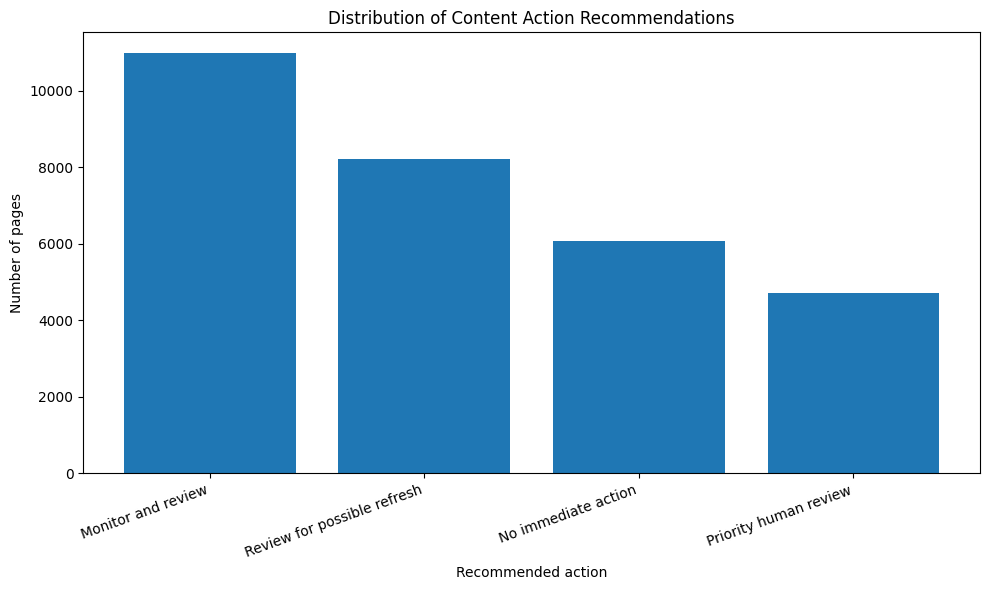


CAPSTONE ARTIFACTS CREATED
- capstone_action_distribution.csv
- capstone_action_distribution.png
- capstone_data_summary.csv
- capstone_full_action_queue.csv
- capstone_model_vs_baseline.csv
- capstone_top_20_recommendations.csv


In [21]:
# ============================================================
# CAPSTONE SECTION 7 — PAPER ARTIFACTS
# ============================================================

import os
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CREATE OUTPUT DIRECTORY
# ------------------------------------------------------------

output_dir = "work/outputs"
os.makedirs(output_dir, exist_ok=True)


# ------------------------------------------------------------
# 1. RESULTS TABLE
# ------------------------------------------------------------

results_path = os.path.join(
    output_dir,
    "capstone_model_vs_baseline.csv"
)

capstone_results.to_csv(
    results_path,
    index=False
)


# ------------------------------------------------------------
# 2. TOP 20 RECOMMENDATIONS
# ------------------------------------------------------------

queue_path = os.path.join(
    output_dir,
    "capstone_top_20_recommendations.csv"
)

top_20.to_csv(
    queue_path,
    index=False
)


# ------------------------------------------------------------
# 3. FULL ACTION QUEUE
# ------------------------------------------------------------

full_queue_path = os.path.join(
    output_dir,
    "capstone_full_action_queue.csv"
)

# Remove client_id if present
safe_recommendations = recommendations.drop(
    columns=["client_id"],
    errors="ignore"
)

safe_recommendations.to_csv(
    full_queue_path,
    index=False
)


# ------------------------------------------------------------
# 4. ACTION DISTRIBUTION
# ------------------------------------------------------------

action_summary_path = os.path.join(
    output_dir,
    "capstone_action_distribution.csv"
)

action_distribution.to_csv(
    action_summary_path,
    index=False
)


# ------------------------------------------------------------
# 5. CREATE ACTION DISTRIBUTION FIGURE
# ------------------------------------------------------------

figure_path = os.path.join(
    output_dir,
    "capstone_action_distribution.png"
)

plt.figure(figsize=(10, 6))

plt.bar(
    action_distribution["Recommended action"],
    action_distribution["Number of pages"]
)

plt.title(
    "Distribution of Content Action Recommendations"
)

plt.xlabel(
    "Recommended action"
)

plt.ylabel(
    "Number of pages"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 6. DATA SUMMARY
# ------------------------------------------------------------

data_summary_path = os.path.join(
    output_dir,
    "capstone_data_summary.csv"
)

data_summary.to_csv(
    data_summary_path,
    index=False
)


# ------------------------------------------------------------
# FINAL OUTPUT CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CAPSTONE ARTIFACTS CREATED")
print("=" * 70)

for filename in sorted(os.listdir(output_dir)):
    print("-", filename)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
